# Daily Births Time Series Analysis (Male vs Female)

**Data source:** `births.csv` (year, month, day, gender, births)

## Important data-quality notes (read before trusting any numbers below)

1. **No COVID-era data exists in this file.** The dataset runs **1969–2008**, ending 12 years
   before COVID-19 (2020). There is no pandemic-era dip to find here — if you were expecting one,
   you're likely thinking of a different/newer dataset. This notebook does **not** attempt a
   post-COVID cutoff for that reason.
2. **Mixed granularity.** Only **1969–1988** has true daily records. **1989–2008** is monthly
   totals only (no `day` value, and birth counts jump ~40x because they're monthly sums, not
   daily counts). Mixing these without adjustment would badly corrupt any daily model.
3. **Invalid calendar dates.** Some rows encode dates that don't exist (e.g. Feb 30, Apr 31,
   Sep 31, a placeholder day of 99) — these are dropped during cleaning.

**Approach:** EDA covers the full 1969–2008 span (daily where available, monthly resampled
where not) so you can see the whole picture. All three forecasting models are built on the
**clean daily 1969–1988 subset**, since that's the only period with real daily granularity to
forecast at a daily level. Male and female series are modeled completely separately throughout.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import xgboost as xgb
from prophet import Prophet

from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)


## Load & Clean Data

In [5]:
df = pd.read_csv("births.csv")
print(df.shape)
df.head()


(15547, 5)


,year,month,day,gender,births
0,1969,1,1.0,F,4046
1,1969,1,1.0,M,4440
2,1969,1,2.0,F,4454
3,1969,1,2.0,M,4548
4,1969,1,3.0,F,4548


In [6]:
# Split into the daily vs monthly 
daily_raw = df[~df["day"].isna()].copy()
monthly_raw = df[df["day"].isna()].copy()

print(f"Daily-granularity rows: {len(daily_raw)}  (years {daily_raw.year.min()}-{daily_raw.year.max()})")
print(f"Monthly-only rows:      {len(monthly_raw)}  (years {monthly_raw.year.min()}-{monthly_raw.year.max()})")


Daily-granularity rows: 15067  (years 1969-1988)
Monthly-only rows:      480  (years 1989-2008)


In [7]:
# clean the data
daily_raw["day"] = daily_raw["day"].astype(int)

# remove impossible calendar dates 
daily_raw["date"] = pd.to_datetime(
    dict(year=daily_raw.year, month=daily_raw.month, day=daily_raw.day),
    errors="coerce"
)

n_before = len(daily_raw)
daily_clean = daily_raw.dropna(subset=["date"]).copy()
print(f"Dropped {n_before - len(daily_clean)} rows with invalid calendar dates "
      f"({(n_before - len(daily_clean))/n_before:.1%})")

daily_clean = daily_clean[["date", "gender", "births"]].sort_values("date").reset_index(drop=True)
daily_clean.head()


Dropped 457 rows with invalid calendar dates (3.0%)


,date,gender,births
0,1969-01-01,F,4046
1,1969-01-01,M,4440
2,1969-01-02,F,4454
3,1969-01-02,M,4548
4,1969-01-03,F,4548


In [8]:
# clean monthly data
monthly_raw["date"] = pd.to_datetime(dict(year=monthly_raw.year, month=monthly_raw.month, day=1))
monthly_clean = monthly_raw[["date", "gender", "births"]].sort_values("date").reset_index(drop=True)
monthly_clean.head()


,date,gender,births
0,1989-01-01,F,156749
1,1989-01-01,M,164052
2,1989-02-01,F,146710
3,1989-02-01,M,154047
4,1989-03-01,F,165889


In [9]:
# create daily pivot
daily_wide = daily_clean.pivot_table(index="date", columns="gender", values="births", aggfunc="sum")
daily_wide = daily_wide.asfreq("D")  # enforce daily frequency, exposes any missing dates as NaN

print("Missing dates in the 1969-1988 daily series:")
print(daily_wide.isna().sum())

# due dilligence check
daily_wide = daily_wide.interpolate(limit=3)
daily_wide.head()


Missing dates in the 1969-1988 daily series:
gender
F    0
M    0
dtype: int64


gender,F,M
date,,
1969-01-01,4046,4440
1969-01-02,4454,4548
1969-01-03,4548,4994
1969-01-04,4440,4520
1969-01-05,4192,4198


## Exploratory Data Analysis

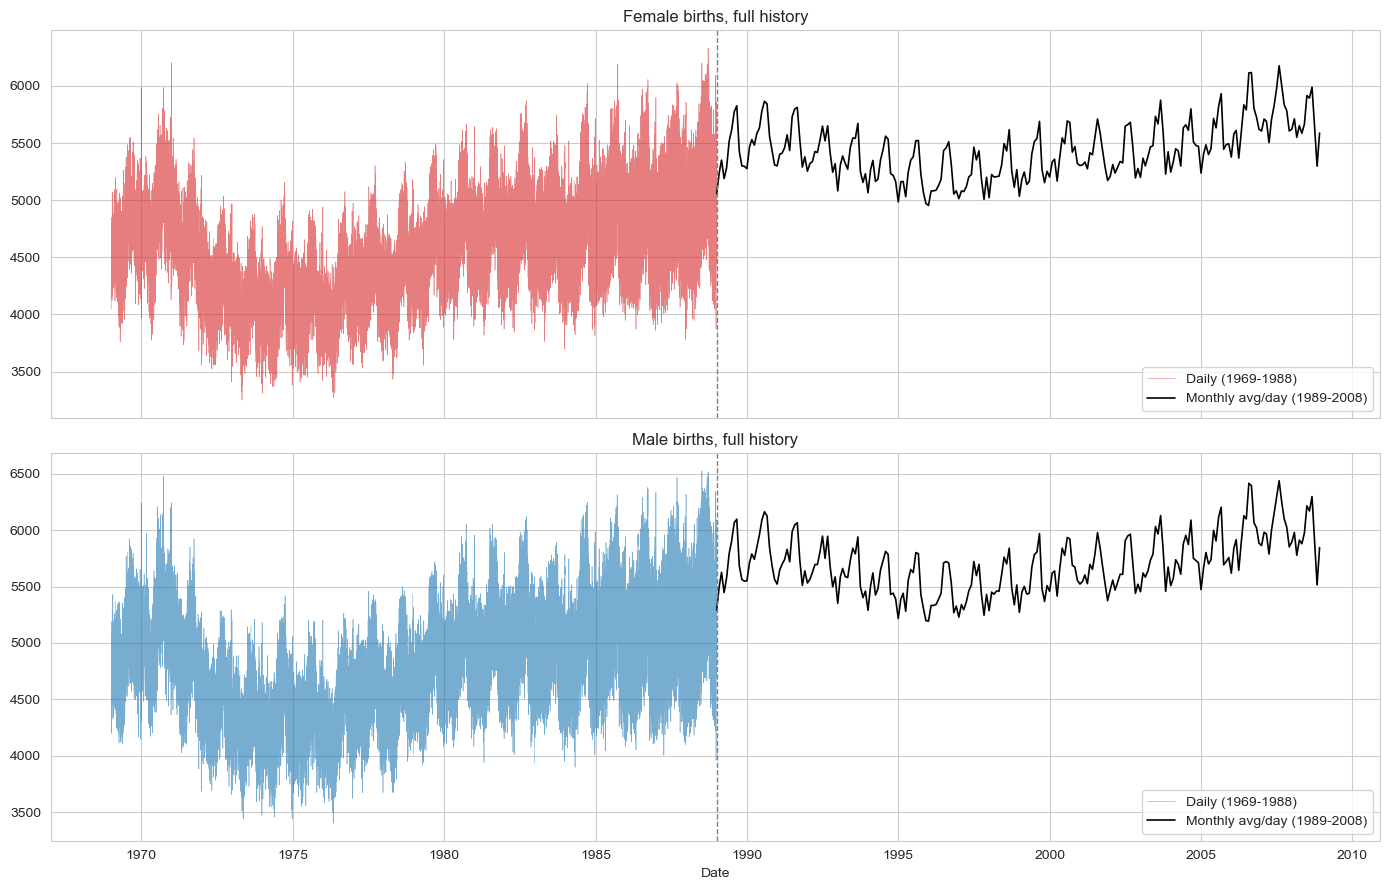

Note the granularity change at the dashed line (1989) — daily noise disappears because
we're plotting monthly averages from that point on, not because births became less variable.


In [10]:
# Daily (1969-1988) + monthly resampled to comparable daily-average scale (1989-2008)
monthly_wide = monthly_clean.pivot_table(index="date", columns="gender", values="births", aggfunc="sum")
# Convert monthly totals to an implied average-per-day so it's visually comparable to the daily series
days_in_month = monthly_wide.index.days_in_month
monthly_avg_per_day = monthly_wide.div(days_in_month, axis=0)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
for ax, gender, color in zip(axes, ["F", "M"], ["tab:red", "tab:blue"]):
    ax.plot(daily_wide.index, daily_wide[gender], lw=0.4, alpha=0.6, color=color, label="Daily (1969-1988)")
    ax.plot(monthly_avg_per_day.index, monthly_avg_per_day[gender], lw=1.2, color="black",
            label="Monthly avg/day (1989-2008)")
    ax.axvline(pd.Timestamp("1989-01-01"), color="gray", ls="--", lw=1)
    ax.set_title(f"{'Female' if gender=='F' else 'Male'} births, full history")
    ax.legend()
plt.xlabel("Date")
plt.tight_layout()
plt.show()

print("Note the granularity change at the dashed line (1989) — daily noise disappears because")
print("we are plotting monthly averages from that point on, not because births became less variable.")


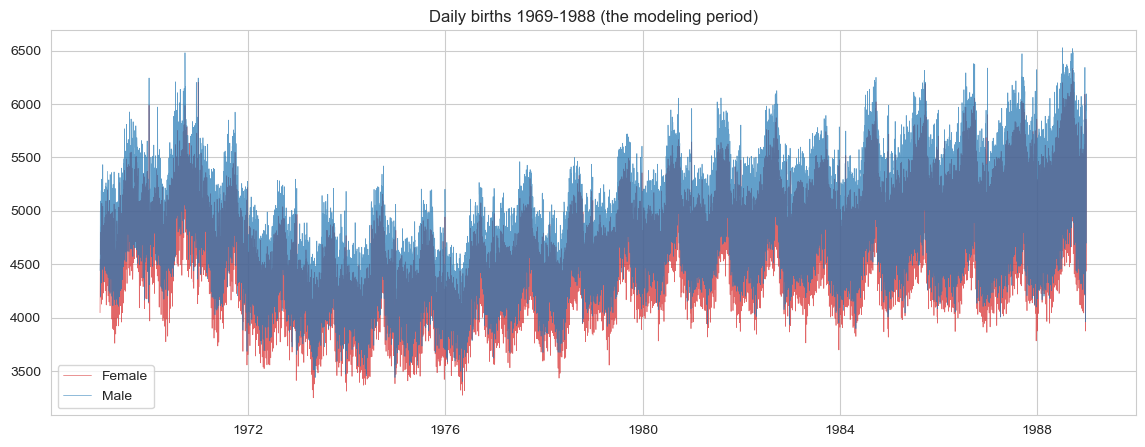

In [11]:
# View of the clean daily period we'll actually model (1969-1988)
fig, ax = plt.subplots()
ax.plot(daily_wide.index, daily_wide["F"], lw=0.5, alpha=0.7, label="Female", color="tab:red")
ax.plot(daily_wide.index, daily_wide["M"], lw=0.5, alpha=0.7, label="Male", color="tab:blue")
ax.set_title("Daily births 1969-1988 (the modeling period)")
ax.legend()
plt.show()


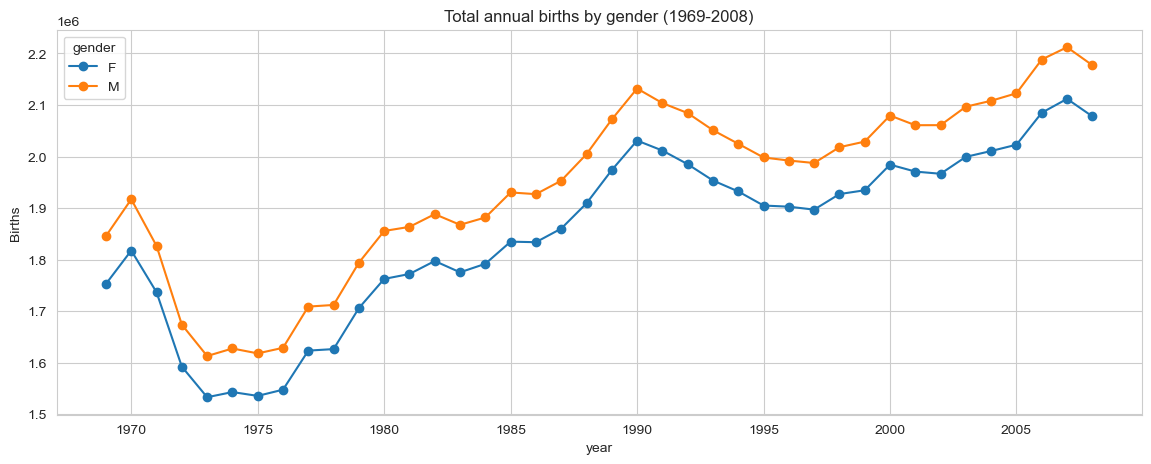

In [12]:
# Yearly totals - check for the well-known long-term birth rate decline over this period,
# and confirm there is no anomaly resembling a COVID-style shock (there shouldn't be - out of range)
yearly = pd.concat([
    daily_clean.assign(year=daily_clean.date.dt.year).groupby(["year","gender"])["births"].sum().unstack(),
    monthly_clean.assign(year=monthly_clean.date.dt.year).groupby(["year","gender"])["births"].sum().unstack()
])
yearly.plot(marker="o", figsize=(14,5), title="Total annual births by gender (1969-2008)")
plt.ylabel("Births")
plt.show()


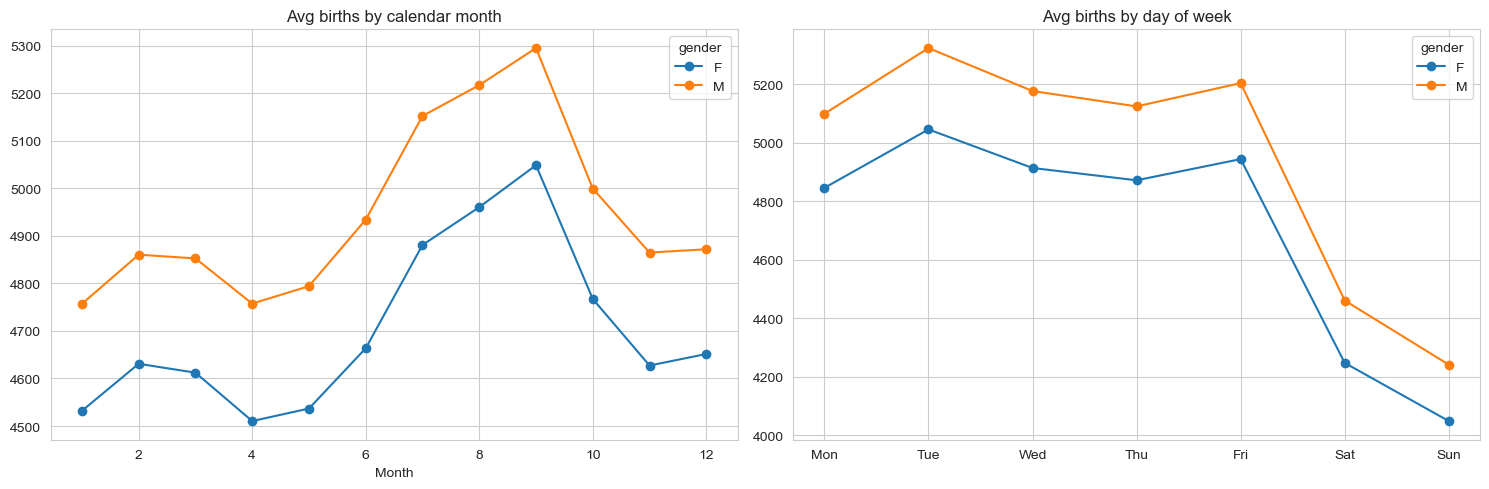

Expect a visible weekday/weekend dip - births skew lower on weekends (fewer scheduled
inductions/C-sections), which matters for choosing seasonal periods (m=7) below.


In [13]:
# Seasonality check: average births by month and by day-of-week (daily period only)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

monthly_seasonality = daily_wide.groupby(daily_wide.index.month).mean()
monthly_seasonality.plot(ax=axes[0], marker="o")
axes[0].set_title("Avg births by calendar month")
axes[0].set_xlabel("Month")

dow_seasonality = daily_wide.groupby(daily_wide.index.dayofweek).mean()
dow_seasonality.index = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
dow_seasonality.plot(ax=axes[1], marker="o")
axes[1].set_title("Avg births by day of week")

plt.tight_layout()
plt.show()

print("Expect a visible weekday/weekend dip - births skew lower on weekends (fewer scheduled")
print("inductions/C-sections), which matters for choosing seasonal periods (m=7) below.")


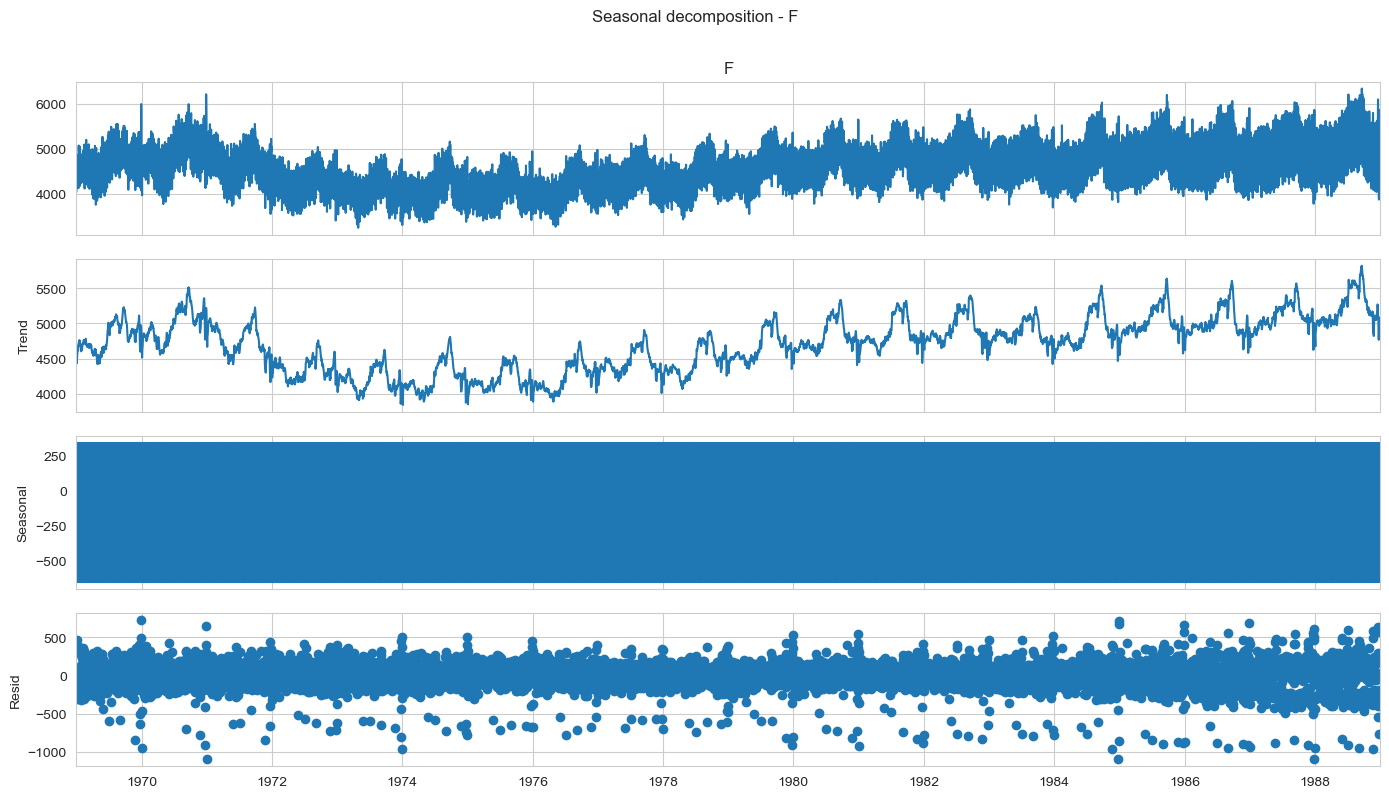

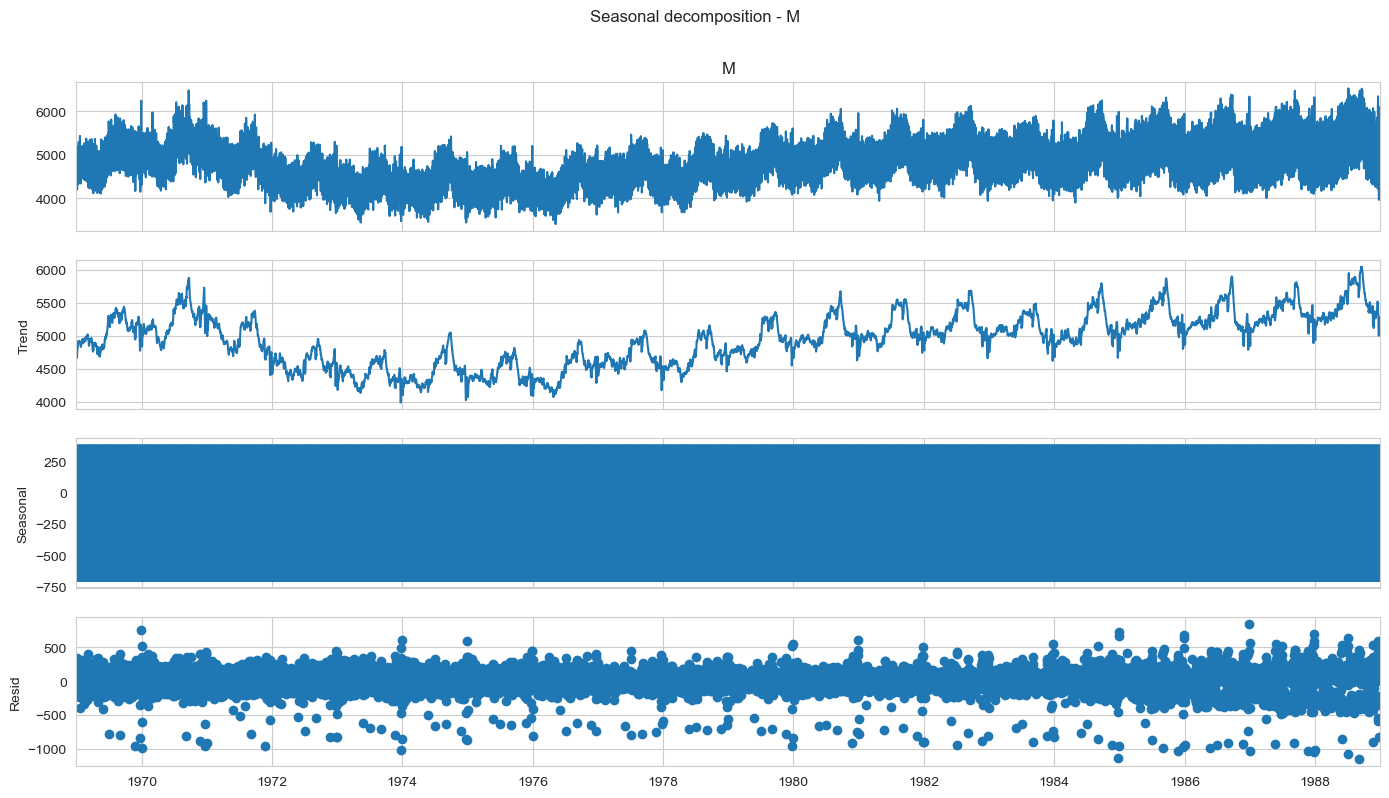

In [14]:
# Seasonal decomposition (additive), weekly seasonality, for each gender
for gender in ["F", "M"]:
    result = seasonal_decompose(daily_wide[gender], model="additive", period=7)
    fig = result.plot()
    fig.set_size_inches(14, 8)
    fig.suptitle(f"Seasonal decomposition - {gender}", y=1.02)
    plt.show()


## Train/Test Split

No COVID cutoff applies (out of range), so we use a standard holdout: the **last 12 months**
of the clean daily series as the test set, everything before that as training.

In [15]:
TEST_DAYS = 365

series = {"F": daily_wide["F"], "M": daily_wide["M"]}
train, test = {}, {}
for g in ["F", "M"]:
    train[g] = series[g].iloc[:-TEST_DAYS]
    test[g]  = series[g].iloc[-TEST_DAYS:]
    print(f"{g}: train {train[g].index.min().date()} to {train[g].index.max().date()} "
          f"({len(train[g])} days), test {test[g].index.min().date()} to {test[g].index.max().date()} "
          f"({len(test[g])} days)")


F: train 1969-01-01 to 1988-01-01 (6940 days), test 1988-01-02 to 1988-12-31 (365 days)
M: train 1969-01-01 to 1988-01-01 (6940 days), test 1988-01-02 to 1988-12-31 (365 days)


## Model 1 — SARIMA

Weekly seasonality (period=7) was visible in the EDA above, so we use a seasonal ARIMA
rather than plain ARIMA. Orders below are reasonable starting points — use `plot_acf`/`plot_pacf`
or `auto_arima` (from `pmdarima`) to tune further if needed.

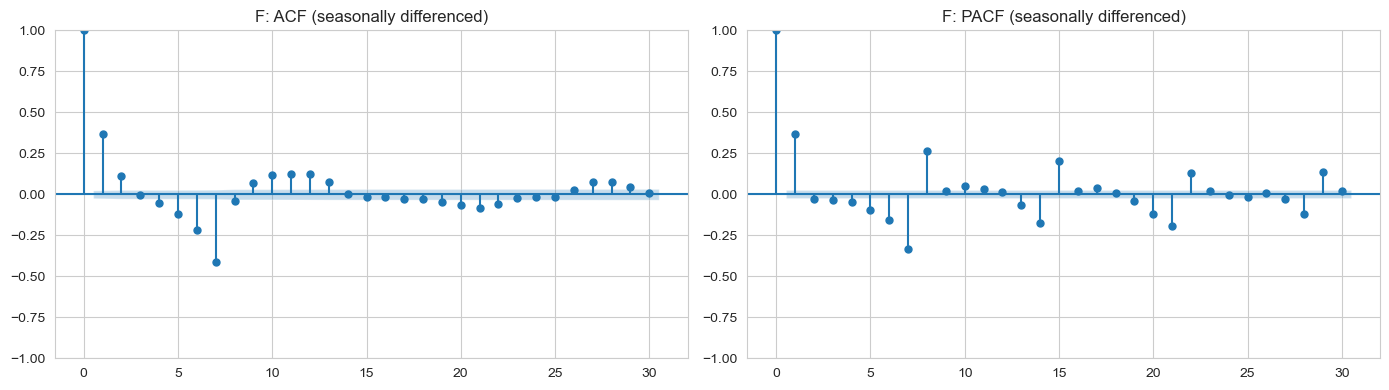

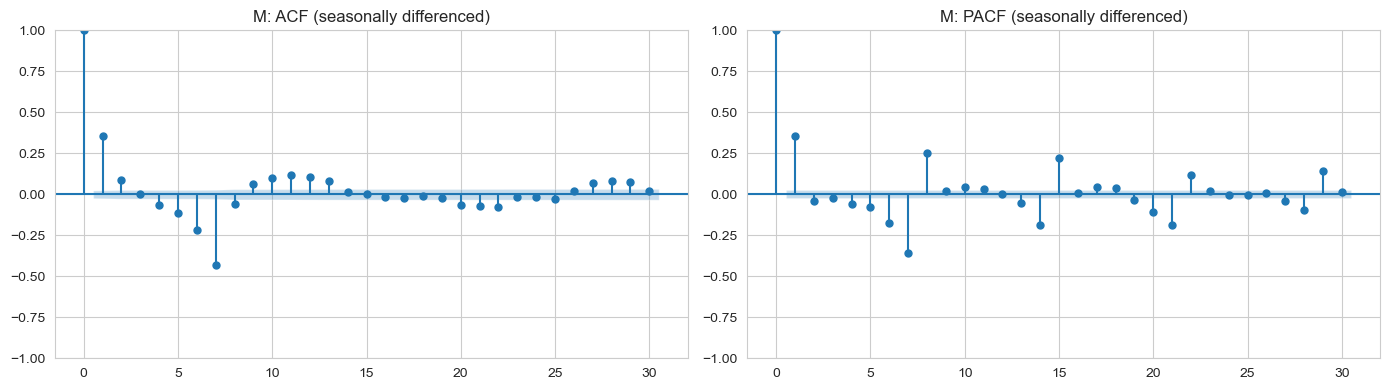

In [16]:
for g in ["F", "M"]:
    fig, axes = plt.subplots(1, 2, figsize=(14,4))
    plot_acf(train[g].diff(7).dropna(), ax=axes[0], lags=30)
    plot_pacf(train[g].diff(7).dropna(), ax=axes[1], lags=30)
    axes[0].set_title(f"{g}: ACF (seasonally differenced)")
    axes[1].set_title(f"{g}: PACF (seasonally differenced)")
    plt.tight_layout()
    plt.show()


In [17]:
sarima_results = {}
sarima_forecasts = {}

for g in ["F", "M"]:
    model = SARIMAX(
        train[g],
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 7),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    fitted = model.fit(disp=False)
    sarima_results[g] = fitted
    sarima_forecasts[g] = fitted.get_forecast(steps=len(test[g])).predicted_mean
    sarima_forecasts[g].index = test[g].index
    print(f"--- {g} SARIMA summary ---")
    print(fitted.summary().tables[1])


--- F SARIMA summary ---
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3654      0.010     37.925      0.000       0.347       0.384
ma.L1         -0.9133      0.006   -152.343      0.000      -0.925      -0.902
ar.S.L7        0.1113      0.009     12.253      0.000       0.094       0.129
ma.S.L7       -0.9766      0.003   -317.843      0.000      -0.983      -0.971
sigma2      2.794e+04    217.412    128.532      0.000    2.75e+04    2.84e+04
--- M SARIMA summary ---
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3606      0.010     36.580      0.000       0.341       0.380
ma.L1         -0.9154      0.006   -154.468      0.000      -0.927      -0.904
ar.S.L7        0.0935      0.008     11.069      0.000       0.077       0.110
ma

## Model 2 — XGBoost

Tree models don't understand time natively, so we engineer lag and calendar features.

In [18]:
def make_features(s: pd.Series, lags=(1,2,3,7,14,28)) -> pd.DataFrame:
    df_feat = pd.DataFrame({"y": s})
    for lag in lags:
        df_feat[f"lag_{lag}"] = s.shift(lag)
    df_feat["dayofweek"] = s.index.dayofweek
    df_feat["month"] = s.index.month
    df_feat["day"] = s.index.day
    df_feat["dayofyear"] = s.index.dayofyear
    return df_feat.dropna()

xgb_models = {}
xgb_forecasts = {}

for g in ["F", "M"]:
    full_feat = make_features(series[g])
    train_feat = full_feat.loc[full_feat.index <= train[g].index.max()]
    test_feat  = full_feat.loc[full_feat.index >= test[g].index.min()]

    X_train, y_train = train_feat.drop(columns="y"), train_feat["y"]
    X_test,  y_test  = test_feat.drop(columns="y"),  test_feat["y"]

    model = xgb.XGBRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=42
    )
    model.fit(X_train, y_train)
    xgb_models[g] = model
    xgb_forecasts[g] = pd.Series(model.predict(X_test), index=X_test.index)

    print(f"{g}: trained on {len(X_train)} rows, predicting {len(X_test)} rows")


F: trained on 6912 rows, predicting 365 rows
M: trained on 6912 rows, predicting 365 rows


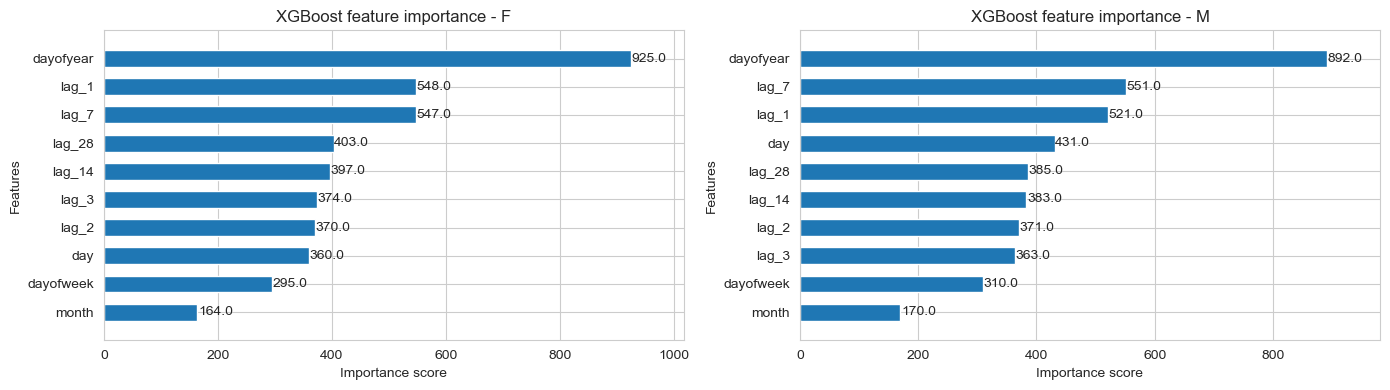

In [19]:
# Feature importance
fig, axes = plt.subplots(1, 2, figsize=(14,4))
for ax, g in zip(axes, ["F","M"]):
    xgb.plot_importance(xgb_models[g], ax=ax, height=0.6)
    ax.set_title(f"XGBoost feature importance - {g}")
plt.tight_layout()
plt.show()


## Model 3 - Prophet

Prophet handles trend + weekly seasonality natively and needs minimal tuning.

In [20]:
prophet_models = {}
prophet_forecasts = {}

for g in ["F", "M"]:
    prophet_df = train[g].reset_index()
    prophet_df.columns = ["ds", "y"]

    model = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
    model.fit(prophet_df)

    future = pd.DataFrame({"ds": test[g].index})
    forecast = model.predict(future)

    prophet_models[g] = model
    prophet_forecasts[g] = pd.Series(forecast["yhat"].values, index=test[g].index)


16:31:06 - cmdstanpy - INFO - Chain [1] start processing
16:31:13 - cmdstanpy - INFO - Chain [1] done processing
16:31:15 - cmdstanpy - INFO - Chain [1] start processing
16:31:21 - cmdstanpy - INFO - Chain [1] done processing


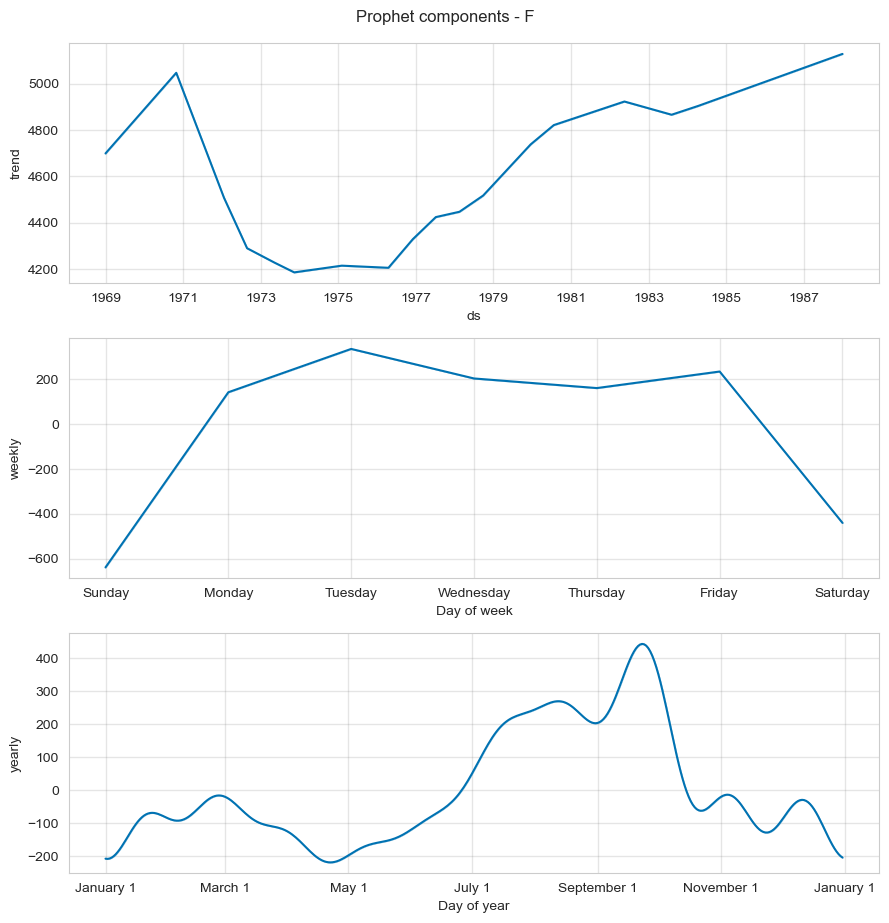

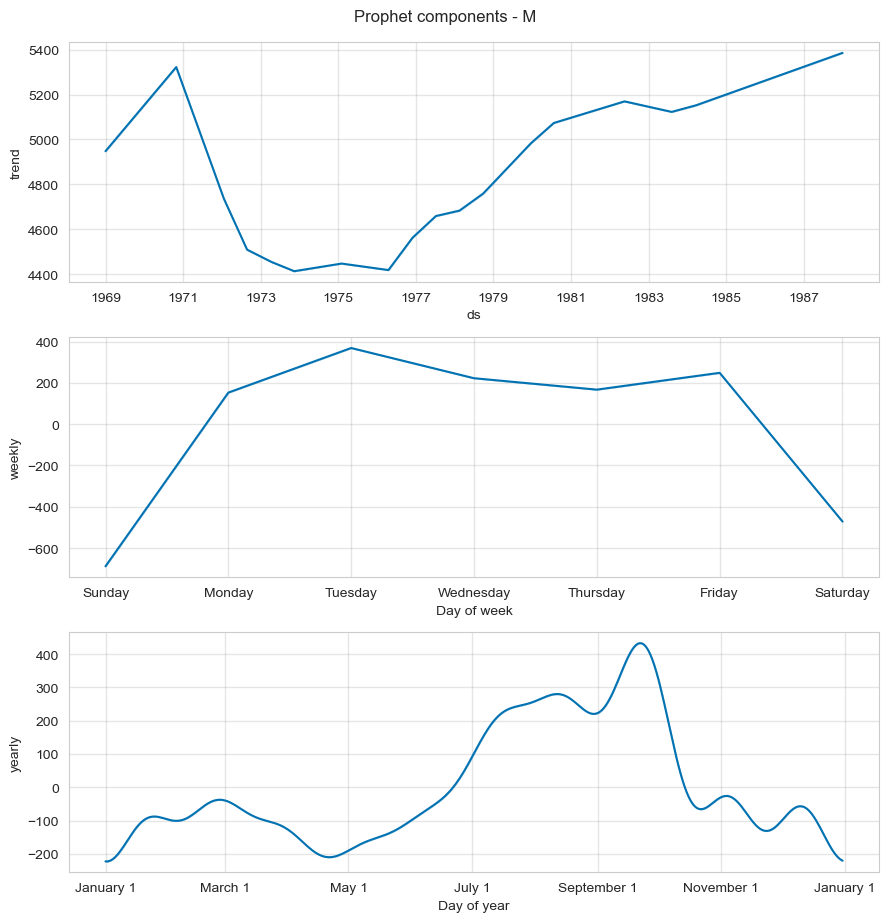

In [21]:
for g in ["F", "M"]:
    fig = prophet_models[g].plot_components(
        prophet_models[g].predict(prophet_models[g].history)
    )
    fig.suptitle(f"Prophet components - {g}", y=1.02)
    plt.show()


## Compare All Three Models

In [22]:
def score(actual, pred, name, gender):
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    return {"gender": gender, "model": name, "MAE": mae, "RMSE": rmse}

rows = []
for g in ["F", "M"]:
    rows.append(score(test[g], sarima_forecasts[g], "SARIMA", g))
    rows.append(score(test[g].loc[xgb_forecasts[g].index], xgb_forecasts[g], "XGBoost", g))
    rows.append(score(test[g], prophet_forecasts[g], "Prophet", g))

results_df = pd.DataFrame(rows)
results_df


,gender,model,MAE,RMSE
0,F,SARIMA,537.972159,619.190632
1,F,XGBoost,124.435501,176.737016
2,F,Prophet,233.808450,282.694820
3,M,SARIMA,579.668146,660.823430
4,M,XGBoost,129.418045,182.736266
5,M,Prophet,249.998146,301.814918
